# Demo Video
**Video URL:** https://YOUR_VIDEO_URL_HERE


**Student:** Kenneth Flynn Gunawan | **NIM:** 2802413871

## 1. Imports & Setup

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')

## 2. Data Loading
Dataset terbagi dua: `A.csv` untuk fitur, `A_targets.csv` untuk target. Kita merge keduanya pakai `Student_ID` sebagai kunci, lalu buang kolom itu setelahnya.


In [81]:
features = pd.read_csv('A.csv')
targets  = pd.read_csv('A_targets.csv')

df = features.merge(targets, on='Student_ID')
df.drop(columns=['Student_ID'], inplace=True)

print('Shape:', df.shape)
df.head()

Shape: (5000, 24)


,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


## 3. Exploratory Data Analysis
### 3.1 Data Types & Basic Info

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       5000 non-null   object 
 1   branch                       5000 non-null   object 
 2   cgpa                         5000 non-null   float64
 3   tenth_percentage             5000 non-null   float64
 4   twelfth_percentage           5000 non-null   float64
 5   backlogs                     5000 non-null   int64  
 6   study_hours_per_day          5000 non-null   float64
 7   attendance_percentage        5000 non-null   float64
 8   projects_completed           5000 non-null   int64  
 9   internships_completed        5000 non-null   int64  
 10  coding_skill_rating          5000 non-null   int64  
 11  communication_skill_rating   5000 non-null   int64  
 12  aptitude_skill_rating        5000 non-null   int64  
 13  hackathons_partici

In [83]:
df.describe()

,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


### 3.2 Missing Values
Hanya `extracurricular_involvement` yang punya missing value, sekitar 1006 baris (20% dari data). Distribusinya cukup balanced, jadi kita isi dengan mode.


In [84]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
extracurricular_involvement    1006
dtype: int64


In [85]:
mode_val = df['extracurricular_involvement'].mode()[0]
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna(mode_val)
print(f'Imputed missing values with mode: "{mode_val}"')
print('Missing values after imputation:', df.isnull().sum().sum())

Imputed missing values with mode: "Medium"
Missing values after imputation: 0


### 3.3 Duplicate

In [86]:
df.duplicated().sum()

np.int64(0)

### 3.4 Target Variable Analysis
Data `placement_status` tidak seimbang: 86% Placed dan 14% Not Placed. Accuracy jadi metrik yang misleading di sini, jadi kita pakai F1 weighted.


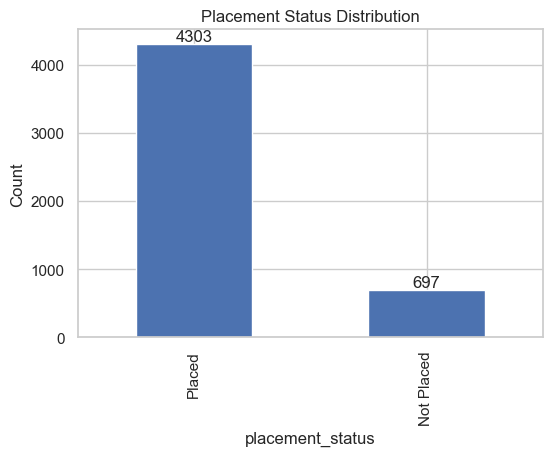

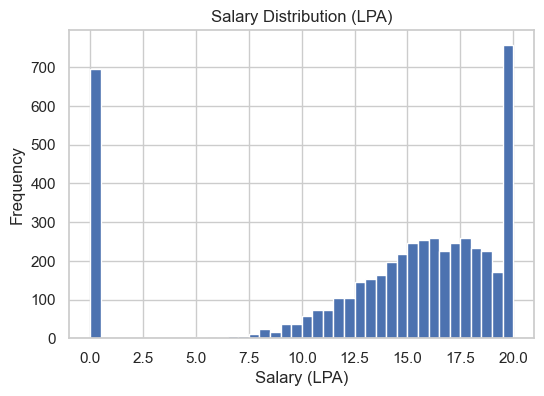

In [87]:
# Classification target
ax = df['placement_status'].value_counts().plot.bar(
    title='Placement Status Distribution', 
    ylabel='Count', 
    figsize=(6, 4)
)
ax.bar_label(ax.containers[0])
plt.show() 

# Regression target
df['salary_lpa'].plot.hist(
    bins=40, 
    title='Salary Distribution (LPA)', 
    figsize=(6, 4)
)
plt.xlabel('Salary (LPA)') 
plt.show() 


### 3.5 Feature Distributions

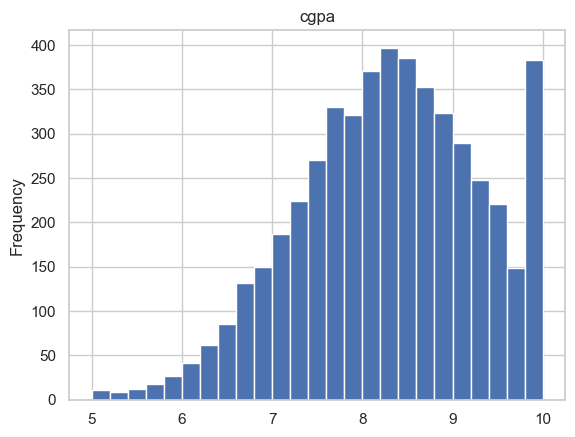

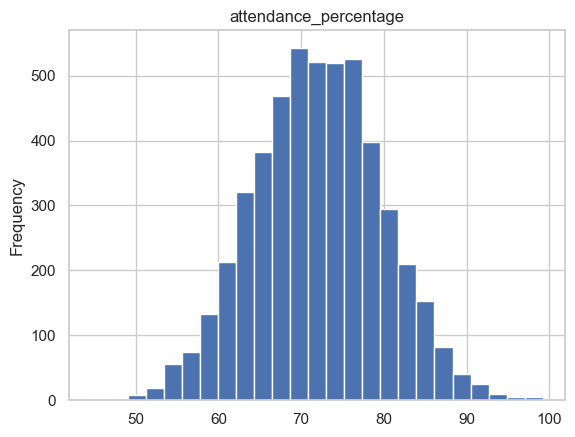

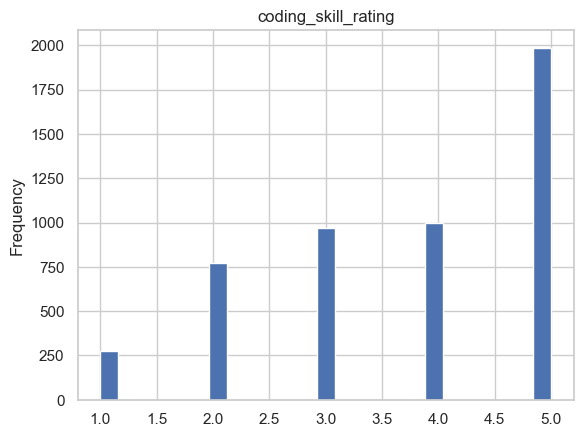

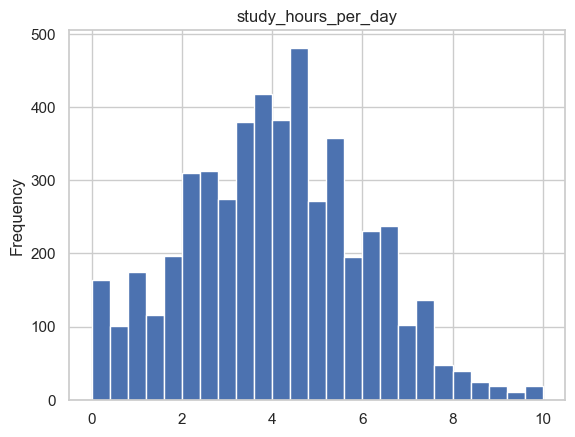

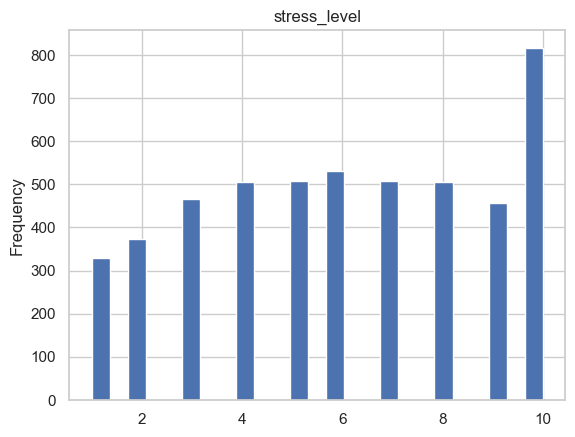

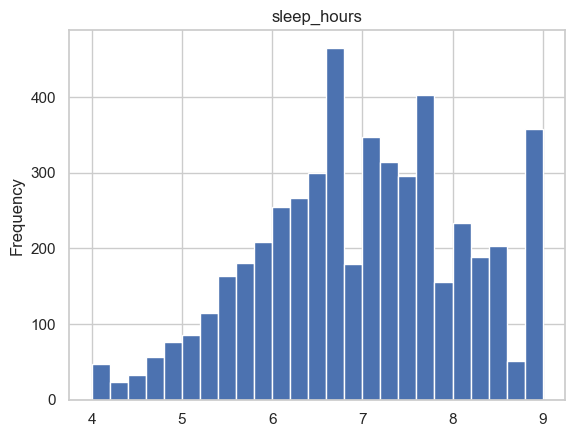

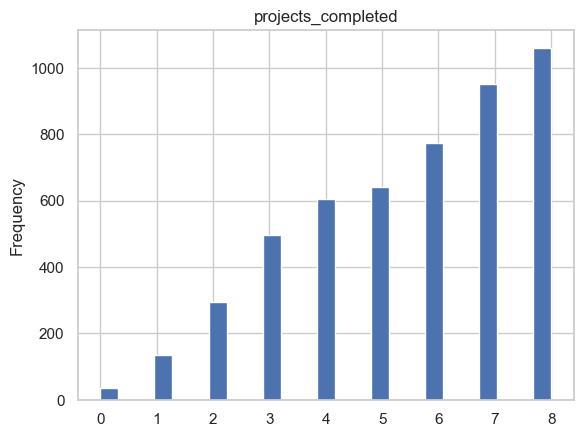

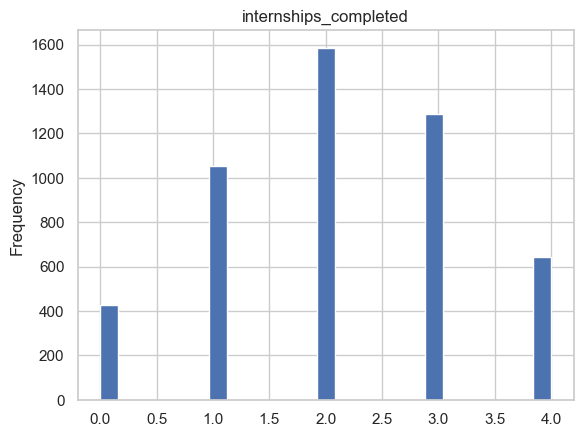

In [88]:
num_cols = ['cgpa', 'attendance_percentage', 'coding_skill_rating',
            'study_hours_per_day', 'stress_level', 'sleep_hours',
            'projects_completed', 'internships_completed']

for col in num_cols:
    df[col].plot.hist(bins=25, title=col)
    plt.show()



### 3.6 Correlation Heatmap
Tiga fitur yang paling berkorelasi ke salary: `cgpa`, `coding_skill_rating`, dan `aptitude_skill_rating`. `backlogs` sebaliknya berkorelasi negatif, sinyal paling jelas untuk placement yang gagal.


Text(0.5, 1.0, 'Correlation Heatmap')

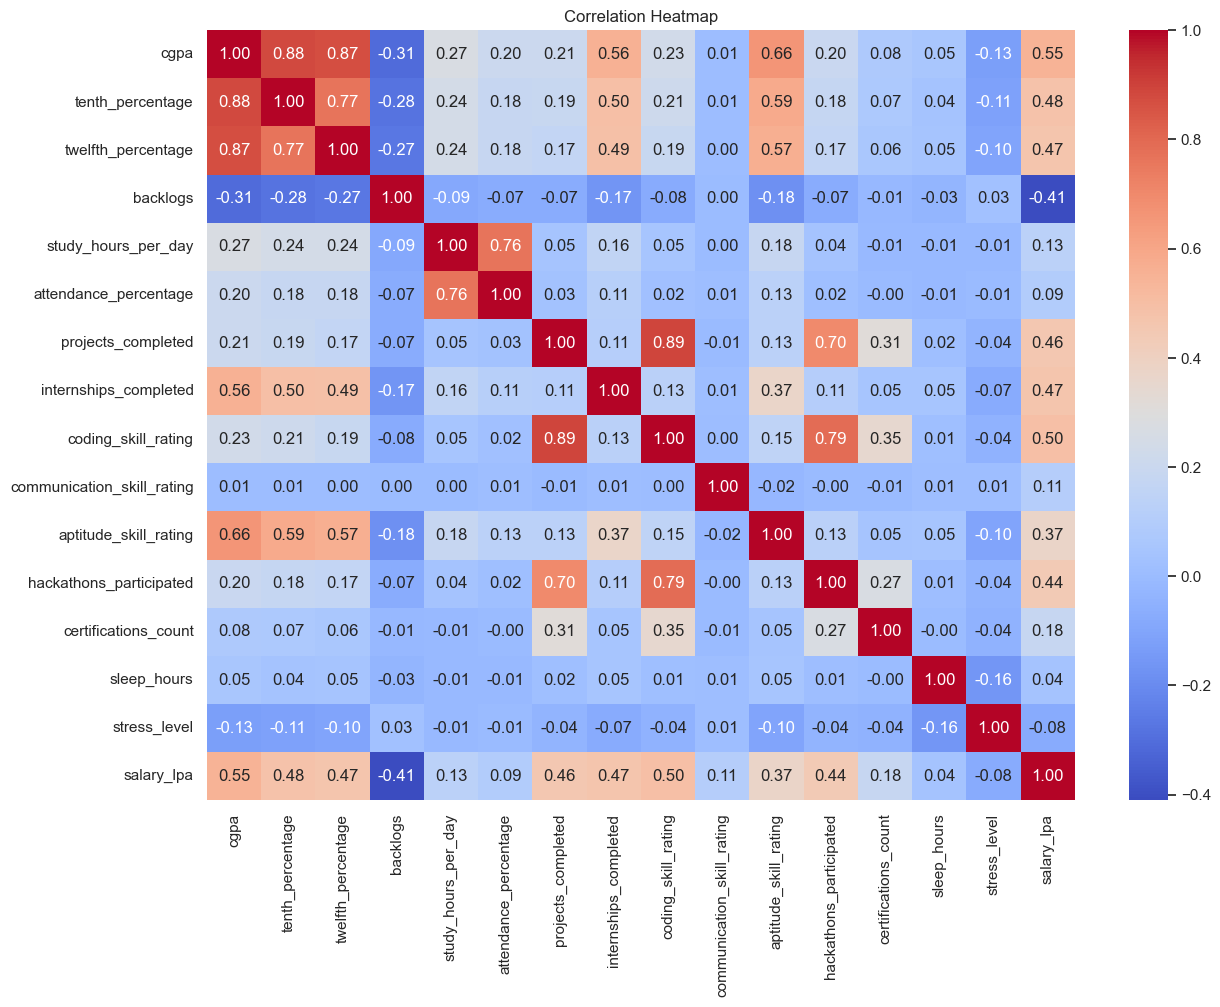

In [89]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')

### 3.7 Categorical Feature Analysis

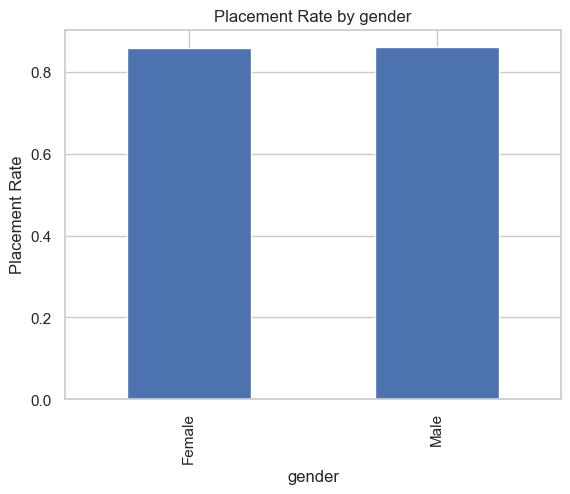

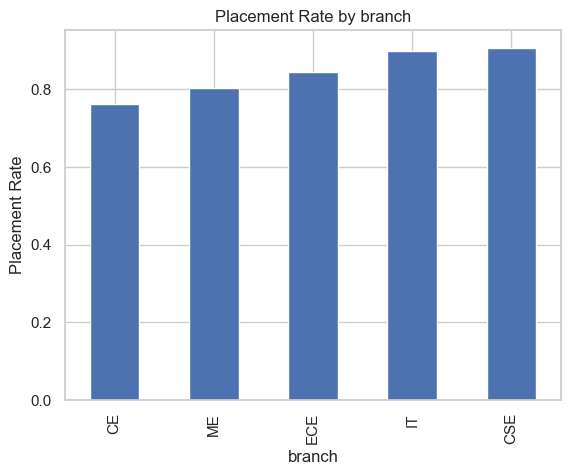

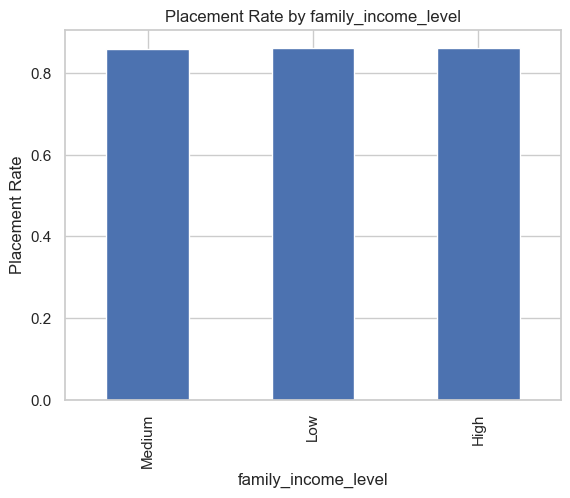

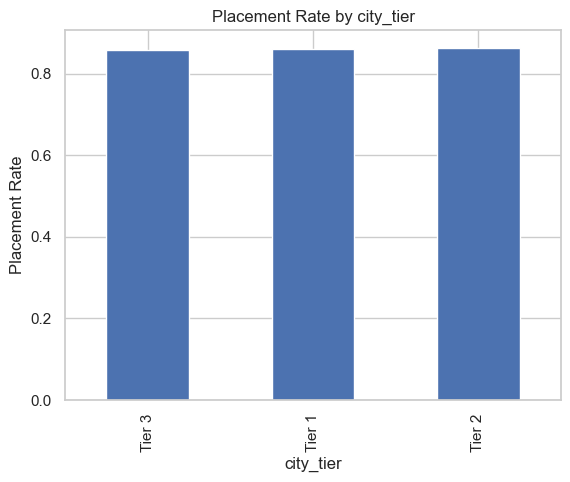

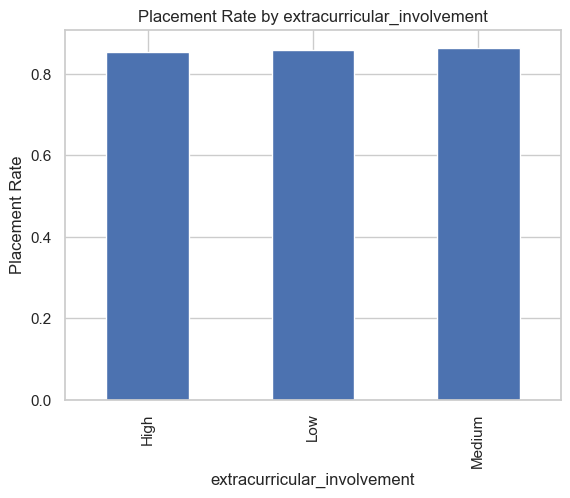

In [90]:
cat_cols = ['gender', 'branch', 'family_income_level', 'city_tier', 'extracurricular_involvement']

# 1. Create a True/False series (True = Placed, False = Not Placed)
is_placed = df['placement_status'] == 'Placed'

for col in cat_cols:
    # 2. Group the True/False series by your category, take the mean, and plot!
    is_placed.groupby(df[col]).mean().sort_values().plot.bar(
        title=f'Placement Rate by {col}', 
        ylabel='Placement Rate',
    )
    plt.show() 


## 4. Feature Engineering

Definisi `CAT_COLS` dan `NUM_COLS` disinkronkan dengan `train_pipeline.py`. Preprocessing dikerjakan lewat `ColumnTransformer` dalam Pipeline: kolom numerik masuk `StandardScaler`, kolom kategorikal masuk `OneHotEncoder`. Target classification di-encode terpisah pakai `LabelEncoder`.


In [91]:
# Column definitions — kept in sync with data_ingestion.py / train.py
CAT_COLS = [
    'gender', 'branch', 'part_time_job', 'family_income_level',
    'city_tier', 'internet_access', 'extracurricular_involvement'
]
NUM_COLS = [
    'cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs',
    'study_hours_per_day', 'attendance_percentage', 'projects_completed',
    'internships_completed', 'coding_skill_rating', 'communication_skill_rating',
    'aptitude_skill_rating', 'hackathons_participated', 'certifications_count',
    'sleep_hours', 'stress_level'
]

# Shared preprocessor — mirrors train.py's build_preprocessor()
def build_preprocessor():
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer(transformers=[
        ('num', num_pipeline, NUM_COLS),
        ('cat', cat_pipeline, CAT_COLS)
    ])


# Encode classification target only
le_target = LabelEncoder()
df['placement_status_enc'] = le_target.fit_transform(df['placement_status'])
print('Target encoding ', le_target.classes_)

Target encoding  ['Not Placed' 'Placed']


### Alasan Pemilihan Fitur

Kolom `Student_ID` langsung dibuang karena hanya identifier, tidak membawa informasi prediktif. Sisanya dibagi dua kelompok.

Fitur numerik mencakup hal yang bisa diukur langsung: nilai akademik (`cgpa`, `tenth_percentage`, `twelfth_percentage`), kebiasaan belajar (`study_hours_per_day`, `attendance_percentage`), dan pencapaian teknis (`coding_skill_rating`, `aptitude_skill_rating`, `projects_completed`, `internships_completed`). Kelompok ini punya korelasi langsung ke employability, seperti yang terlihat di heatmap section 3.6.

Fitur kategorikal masuk karena mewakili konteks yang relevan: `family_income_level` dan `city_tier` mencerminkan akses ke peluang karier, `branch` menentukan pasar kerja yang tersedia, dan `extracurricular_involvement` memberi sinyal soft skill. `backlogs` sengaja dipertahankan meski nilainya kecil karena terbukti berkorelasi negatif dengan placement.


## 5. Train-Test Split (80:20)
Pakai split 80/20 dengan stratify, supaya proporsi kelas tetap terjaga di kedua subset.


In [92]:
X      = df.drop(columns=['placement_status', 'placement_status_enc', 'salary_lpa'])
y_clf  = df['placement_status_enc']
y_reg  = df['salary_lpa']

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train placement balance:\n{yc_train.value_counts()}')

Train: (4000, 22), Test: (1000, 22)
Train placement balance:
placement_status_enc
1    3442
0     558
Name: count, dtype: int64


## 6. Classification Models

Lima model classification dicoba dengan Pipeline yang sama. Karena data imbalanced, metrik utama yang kita lihat adalah F1 weighted.


In [93]:
clf_models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'KNN': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
    ])
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train, yc_train)
    preds = model.predict(X_test)
    f1 = f1_score(yc_test, preds, average='weighted')
    clf_results[name] = {'model': model, 'f1': f1, 'preds': preds}
    print(f'\n{"="*40}')
    print(f'{name} — F1 (weighted): {f1:.4f}')
    print(classification_report(yc_test, preds, target_names=le_target.classes_))



Logistic Regression — F1 (weighted): 0.8828
              precision    recall  f1-score   support

  Not Placed       0.65      0.46      0.54       139
      Placed       0.92      0.96      0.94       861

    accuracy                           0.89      1000
   macro avg       0.78      0.71      0.74      1000
weighted avg       0.88      0.89      0.88      1000


KNN — F1 (weighted): 0.8521
              precision    recall  f1-score   support

  Not Placed       0.54      0.31      0.39       139
      Placed       0.90      0.96      0.93       861

    accuracy                           0.87      1000
   macro avg       0.72      0.63      0.66      1000
weighted avg       0.85      0.87      0.85      1000


Decision Tree — F1 (weighted): 0.8459
              precision    recall  f1-score   support

  Not Placed       0.45      0.41      0.43       139
      Placed       0.91      0.92      0.91       861

    accuracy                           0.85      1000
   macro avg   

Best Classifier: Logistic Regression (F1=0.8828)


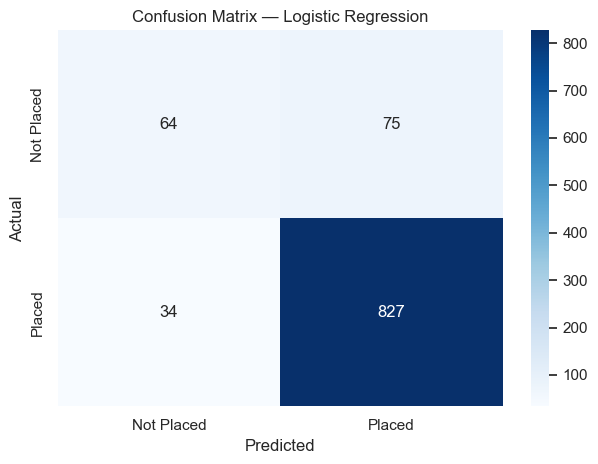

In [94]:
# Confusion matrix for best classifier
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['f1'])
print(f'Best Classifier: {best_clf_name} (F1={clf_results[best_clf_name]["f1"]:.4f})')

cm = confusion_matrix(yc_test, clf_results[best_clf_name]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix — {best_clf_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Interpretasi Metrik Classification

F1 weighted dipilih karena distribusi kelas tidak seimbang (86% Placed, 14% Not Placed). Accuracy bisa terlihat tinggi meskipun model hanya nebak "Placed" terus, jadi F1 lebih jujur mengukur performa di kedua kelas.

Logistic Regression meraih F1 = 0.8828. Confusion matrix di atas menunjukkan model lebih sering salah di kelas minoritas (Not Placed), yang wajar karena data training didominasi kelas Placed. Jika precision untuk Not Placed masih rendah, artinya ada banyak false positive: kandidat yang diprediksi tidak akan placed ternyata placed. Ini acceptable untuk screening awal, tapi perlu diperhatikan kalau dipakai untuk keputusan final.


## 7. Regression Models

Lima model regression diuji dengan setup yang sama. Metrik utama RMSE, tapi R² juga dicek untuk tahu seberapa banyak variance salary yang bisa dijelaskan model.


In [95]:
reg_models = {
    'Linear Regression': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', LinearRegression())
    ]),
    'KNN': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', KNeighborsRegressor())
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', DecisionTreeRegressor(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', XGBRegressor(n_estimators=100, random_state=42))
    ])
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train, yr_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(yr_test, preds))
    r2   = r2_score(yr_test, preds)
    mae  = mean_absolute_error(yr_test, preds)
    reg_results[name] = {'model': model, 'rmse': rmse, 'r2': r2, 'mae': mae, 'preds': preds}
    print(f'{name:25s} — RMSE: {rmse:.4f} | R²: {r2:.4f} | MAE: {mae:.4f}')


Linear Regression         — RMSE: 3.9948 | R²: 0.5877 | MAE: 2.8387
KNN                       — RMSE: 4.5478 | R²: 0.4657 | MAE: 2.9609
Decision Tree             — RMSE: 5.4875 | R²: 0.2221 | MAE: 3.1731
Random Forest             — RMSE: 4.0750 | R²: 0.5710 | MAE: 2.7065
XGBoost                   — RMSE: 4.2244 | R²: 0.5390 | MAE: 2.7749


Best Regressor: Linear Regression (RMSE=3.9948)


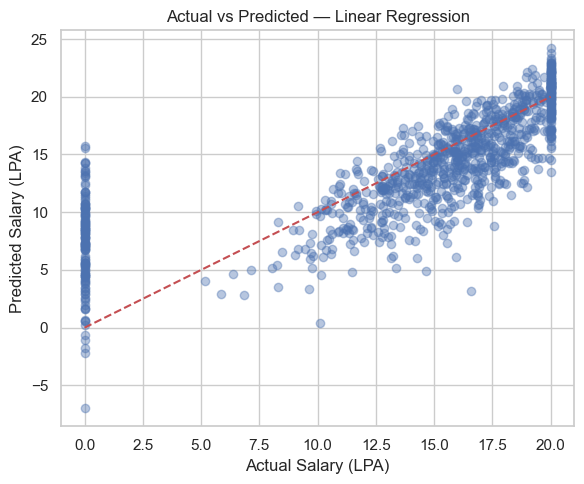

In [96]:
# Actual vs Predicted for best regressor
best_reg_name = min(reg_results, key=lambda k: reg_results[k]['rmse'])
print(f'Best Regressor: {best_reg_name} (RMSE={reg_results[best_reg_name]["rmse"]:.4f})')

best_reg_preds = reg_results[best_reg_name]['preds']
plt.figure(figsize=(6, 5))
plt.scatter(yr_test, best_reg_preds, alpha=0.4)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.xlabel('Actual Salary (LPA)')
plt.ylabel('Predicted Salary (LPA)')
plt.title(f'Actual vs Predicted — {best_reg_name}')
plt.tight_layout()
plt.show()


### Interpretasi Metrik Regression

Tiga metrik dipakai supaya evaluasi lebih lengkap dan tidak bergantung pada satu angka saja.

RMSE mengukur error rata-rata dalam satuan LPA. Nilai 3.9948 berarti prediksi model meleset sekitar 4 LPA dari nilai aktual. Karena RMSE menghukum error besar lebih keras (dikuadratkan dulu), angka ini juga sinyal ada tidaknya outlier error yang parah.

MAE tidak dikuadratkan, jadi lebih stabil. Kalau MAE jauh lebih kecil dari RMSE, itu tanda beberapa prediksi meleset sangat jauh dan menarik rata-rata ke atas.

R² = 0.5877 berarti model menjelaskan sekitar 59% dari variasi salary. Sisanya dipengaruhi faktor yang tidak ada di dataset: negosiasi gaji, reputasi kampus, timing melamar, dan sebagainya. Untuk data pendidikan ini bukan angka yang buruk, tapi tidak cukup presisi kalau dipakai untuk prediksi salary individual.


## 8. Model Selection Summary

Logistic Regression menang di classification (F1 = 0.8828). Masuk akal, karena setelah scaling pattern-nya cukup linear. Di sisi regression, Linear Regression juga yang terbaik (RMSE = 3.9948, R² = 0.5877). R²-nya memang belum ideal, tapi wajar karena banyak faktor penentu salary yang tidak tercakup di dataset ini.

Fitur paling berpengaruh: `cgpa`, `coding_skill_rating`, dan `aptitude_skill_rating`. `backlogs` konsisten jadi sinyal negatif paling jelas.


In [97]:
print('FINAL MODEL COMPARISON')
print('\nClassification (higher F1 = better):')
for name, r in sorted(clf_results.items(), key=lambda x: -x[1]['f1']):
    print(f'  {name:25s}: F1 = {r["f1"]:.4f}')

print('\nRegression (lower RMSE = better):')
for name, r in sorted(reg_results.items(), key=lambda x: x[1]['rmse']):
    print(f'  {name:25s}: RMSE = {r["rmse"]:.4f} | R² = {r["r2"]:.4f}')

print(f'\nBest Classifier : {best_clf_name}')
print(f'Best Regressor  : {best_reg_name}')

FINAL MODEL COMPARISON

Classification (higher F1 = better):
  Logistic Regression      : F1 = 0.8828
  Random Forest            : F1 = 0.8662
  XGBoost                  : F1 = 0.8656
  KNN                      : F1 = 0.8521
  Decision Tree            : F1 = 0.8459

Regression (lower RMSE = better):
  Linear Regression        : RMSE = 3.9948 | R² = 0.5877
  Random Forest            : RMSE = 4.0750 | R² = 0.5710
  XGBoost                  : RMSE = 4.2244 | R² = 0.5390
  KNN                      : RMSE = 4.5478 | R² = 0.4657
  Decision Tree            : RMSE = 5.4875 | R² = 0.2221

Best Classifier : Logistic Regression
Best Regressor  : Linear Regression
